In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd
import numpy as np
import cv2
import os

# Path ke file CSV dan folder penyimpanan
csv_path = '/content/drive/MyDrive/PDM/hand_landmarks_video2.csv'
output_folder = '/content/drive/MyDrive/PDM/hand_landmarks_CITRA2d'  # Folder utama

# Baca file CSV
df = pd.read_csv(csv_path)

# Ukuran kanvas gambar 2D
canvas_size = 224  # Bisa gunakan 224 atau 256 untuk ukuran gambar

# Dictionary untuk menghitung jumlah gambar yang disimpan per kelas
class_counts = {}
max_images_per_class = 600

# Iterasi melalui setiap baris dalam DataFrame
for index, row in df.iterrows():
    # Ekstrak label kelas
    class_label = row['class_label']

    # Inisialisasi hitungan untuk kelas jika belum ada
    if class_label not in class_counts:
        class_counts[class_label] = 0

    # Cek apakah jumlah gambar untuk kelas ini sudah mencapai batas
    if class_counts[class_label] < max_images_per_class:
        # Ekstrak koordinat landmark (x, y, z)
        num_landmarks = 21  # Jumlah landmark per tangan (kanan dan kiri)
        x_coords = []
        y_coords = []

        for i in range(1, num_landmarks + 1):
            # Ambil koordinat x dan y untuk tangan kanan
            x_coords.append(row[f'right_x{i}'])
            y_coords.append(row[f'right_y{i}'])
            # Ambil koordinat x dan y untuk tangan kiri
            x_coords.append(row[f'left_x{i}'])
            y_coords.append(row[f'left_y{i}'])

        # Ubah list ke NumPy array dan tangani NaN
        x_coords = np.nan_to_num(np.array(x_coords), 0)
        y_coords = np.nan_to_num(np.array(y_coords), 0)

        # Hitung rentang dan skala untuk memastikan penyebaran yang baik
        min_x, max_x = np.min(x_coords), np.max(x_coords)
        min_y, max_y = np.min(y_coords), np.max(y_coords)

        # Menyesuaikan skala untuk menempatkan tangan dalam batas kanvas
        scale_x = (canvas_size - 10) / (max_x - min_x) if max_x > min_x else 1  # Padding 10 untuk margin
        scale_y = (canvas_size - 10) / (max_y - min_y) if max_y > min_y else 1

        # Tentukan offset agar titik berada di tengah kanvas
        offset_x = (canvas_size - (max_x * scale_x)) // 2
        offset_y = (canvas_size - (max_y * scale_y)) // 2


        # Buat path folder untuk label kelas (A-Z)
        class_folder = os.path.join(output_folder, class_label)
        os.makedirs(class_folder, exist_ok=True)

        # Buat kanvas grayscale dengan ukuran 224x224
        canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

        # Gambar landmark pada kanvas dengan ukuran titik yang lebih besar
        for x, y in zip(x_coords, y_coords):
            x_coord = int((x - min_x) * scale_x + offset_x)  # Skalakan dan sesuaikan dengan offset
            y_coord = int((y - min_y) * scale_y + offset_y)  # Skalakan dan sesuaikan dengan offset

            # Pastikan titik berada dalam batas kanvas
            if 0 <= x_coord < canvas_size and 0 <= y_coord < canvas_size:
                cv2.circle(canvas, (x_coord, y_coord), 6, (255, 255, 255), -1)  # Ukuran titik yang lebih besar

        # Simpan gambar ke folder kelas
        # Gunakan hitungan kelas sebagai nama file
        image_path = os.path.join(class_folder, f'{class_counts[class_label]}.png')
        cv2.imwrite(image_path, canvas)

        print(f'Gambar landmark untuk baris {index} (label {class_label}) disimpan di {image_path}')

        # Tambahkan hitungan untuk kelas ini
        class_counts[class_label] += 1
    else:
        print(f'Batas 600 gambar per kelas sudah tercapai untuk label {class_label}. Melewati baris ini.')

print('Proses selesai!')

Streaming output truncated to the last 5000 lines.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kelas sudah tercapai untuk label X. Melewati baris ini.
Batas 600 gambar per kela

In [ ]:
import os

output_folder = '/content/drive/MyDrive/PDM/hand_landmarks_CITRA2d'  # Folder utama

# Dictionary untuk menyimpan hitungan gambar per kelas
class_totals = {}
total_images = 0

# Iterasi melalui setiap item dalam folder output
for item in os.listdir(output_folder):
    item_path = os.path.join(output_folder, item)

    # Cek apakah item tersebut adalah folder (merepresentasikan kelas)
    if os.path.isdir(item_path):
        class_label = item
        class_totals[class_label] = 0

        # Hitung jumlah file (gambar) dalam folder kelas
        for filename in os.listdir(item_path):
            if filename.endswith('.png'): # Pastikan hanya menghitung file gambar PNG
                class_totals[class_label] += 1
                total_images += 1

# Tampilkan total per kelas
print("Total gambar per kelas:")
for class_label, count in sorted(class_totals.items()):
    print(f"Kelas {class_label}: {count} gambar")

# Tampilkan total keseluruhan
print(f"\nTotal keseluruhan gambar: {total_images} gambar")

Total gambar per kelas:
Kelas A: 600 gambar
Kelas B: 600 gambar
Kelas C: 600 gambar
Kelas D: 600 gambar
Kelas E: 600 gambar
Kelas F: 600 gambar
Kelas G: 600 gambar
Kelas H: 600 gambar
Kelas I: 600 gambar
Kelas J: 600 gambar
Kelas K: 600 gambar
Kelas L: 600 gambar
Kelas M: 600 gambar
Kelas N: 600 gambar
Kelas O: 600 gambar
Kelas P: 600 gambar
Kelas Q: 600 gambar
Kelas R: 600 gambar
Kelas S: 600 gambar
Kelas T: 600 gambar
Kelas U: 600 gambar
Kelas V: 600 gambar
Kelas W: 600 gambar
Kelas X: 600 gambar
Kelas Y: 600 gambar
Kelas Z: 600 gambar

Total keseluruhan gambar: 15600 gambar


In [ ]:
import pandas as pd
import numpy as np
import cv2
import os

# Path ke file CSV dan folder penyimpanan
csv_path = '/content/drive/MyDrive/PDM/hand_landmarks_gambar.csv'
output_folder = '/content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d'  # Folder utama

# Baca file CSV
df = pd.read_csv(csv_path)

# Ukuran kanvas gambar 2D
canvas_size = 224  # Bisa gunakan 224 atau 256 untuk ukuran gambar

# Iterasi melalui setiap baris dalam DataFrame
for index, row in df.iterrows():
    # Ekstrak label kelas
    class_label = row['class_label']

    # Ekstrak koordinat landmark (x, y, z)
    num_landmarks = 21  # Jumlah landmark per tangan (kanan dan kiri)
    x_coords = []
    y_coords = []

    for i in range(1, num_landmarks + 1):
        # Ambil koordinat x dan y untuk tangan kanan
        x_coords.append(row[f'right_x{i}'])
        y_coords.append(row[f'right_y{i}'])
        # Ambil koordinat x dan y untuk tangan kiri
        x_coords.append(row[f'left_x{i}'])
        y_coords.append(row[f'left_y{i}'])

    # Ubah list ke NumPy array dan tangani NaN
    x_coords = np.nan_to_num(np.array(x_coords), 0)
    y_coords = np.nan_to_num(np.array(y_coords), 0)

    # Hitung rentang dan skala untuk memastikan penyebaran yang baik
    min_x, max_x = np.min(x_coords), np.max(x_coords)
    min_y, max_y = np.min(y_coords), np.max(y_coords)

    # Menyesuaikan skala untuk menempatkan tangan dalam batas kanvas
    scale_x = (canvas_size - 10) / (max_x - min_x) if max_x > min_x else 1  # Padding 10 untuk margin
    scale_y = (canvas_size - 10) / (max_y - min_y) if max_y > min_y else 1

    # Tentukan offset agar titik berada di tengah kanvas
    offset_x = (canvas_size - (max_x * scale_x)) // 2
    offset_y = (canvas_size - (max_y * scale_y)) // 2

    # Buat path folder untuk label kelas (A-Z)
    class_folder = os.path.join(output_folder, class_label)
    os.makedirs(class_folder, exist_ok=True)

    # Buat kanvas grayscale dengan ukuran 224x224
    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    # Gambar landmark pada kanvas dengan ukuran titik yang lebih besar
    for x, y in zip(x_coords, y_coords):
        x_coord = int((x - min_x) * scale_x + offset_x)  # Skalakan dan sesuaikan dengan offset
        y_coord = int((y - min_y) * scale_y + offset_y)  # Skalakan dan sesuaikan dengan offset

        # Pastikan titik berada dalam batas kanvas
        if 0 <= x_coord < canvas_size and 0 <= y_coord < canvas_size:
            cv2.circle(canvas, (x_coord, y_coord), 6, (255, 255, 255), -1)  # Ukuran titik yang lebih besar

    # Simpan gambar ke folder kelas
    image_path = os.path.join(class_folder, f'{index}.png')
    cv2.imwrite(image_path, canvas)

    print(f'Gambar landmark untuk baris {index} (label {class_label}) disimpan di {image_path}')

print('Proses selesai!')


Gambar landmark untuk baris 0 (label N) disimpan di /content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d/N/0.png
Gambar landmark untuk baris 1 (label N) disimpan di /content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d/N/1.png
Gambar landmark untuk baris 2 (label N) disimpan di /content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d/N/2.png
Gambar landmark untuk baris 3 (label N) disimpan di /content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d/N/3.png
Gambar landmark untuk baris 4 (label N) disimpan di /content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d/N/4.png
Gambar landmark untuk baris 5 (label N) disimpan di /content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d/N/5.png
Gambar landmark untuk baris 6 (label N) disimpan di /content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d/N/6.png
Gambar landmark untuk baris 7 (label N) disimpan di /content/drive/MyDrive/PDM/hand_landmarks_gambar_CITRA2d/N/7.png
Gambar landmark untuk baris 8 (label N) disimpan di /content/dri

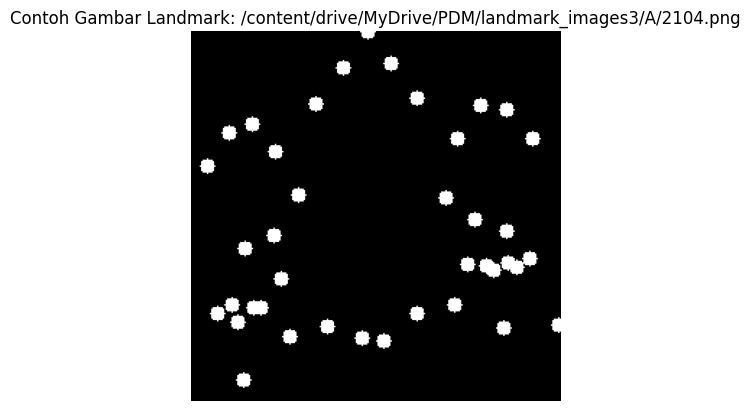

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
from google.colab import drive


# Path ke folder penyimpanan gambar 2D
output_folder = '/content/drive/MyDrive/PDM/landmark_images3'  # Folder utama

# Pilih path ke salah satu gambar yang ingin ditampilkan
# Ganti 'A' dengan label kelas yang Anda inginkan dan 0 dengan indeks gambar
# Anda perlu memastikan folder dan file ini ada setelah menjalankan kode sebelumnya.
sample_class = 'A' # Ganti dengan label kelas yang ada
sample_index = 2104  # Ganti dengan indeks gambar yang ada
sample_image_path = os.path.join(output_folder, sample_class, f'{sample_index}.png')

# Cek apakah gambar sampel ada
if os.path.exists(sample_image_path):
    # Baca gambar
    sample_image = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)

    # Tampilkan gambar
    plt.imshow(sample_image, cmap='gray')
    plt.title(f'Contoh Gambar Landmark: {sample_image_path}')
    plt.axis('off') # Sembunyikan sumbu
    plt.show()
else:
    print(f'Gambar sampel tidak ditemukan di {sample_image_path}')
    print(f'Pastikan folder "{os.path.join(output_folder, sample_class)}" dan file "{sample_index}.png" ada.')